In [1]:
import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

from src.config import MODEL_CLASSES
import src.api.result as result_api


RESULTS_DIR = os.path.join("results")

# Shuffle

In [2]:
def load_results(model_name, component):
    fname = f"{model_name}_shuffle_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    results = [result_api.CopyingResult(**r) for r in results]

    return results


def summarise_results(results, type="prob"):
    d = {}

    for r in results:
        if "shuffle_meta" in r.model_details:
            shuffle_meta = r.model_details["shuffle_meta"]
            shuffle_type = shuffle_meta["shuffled_type"]
            if shuffle_type not in d:
                d[shuffle_type] = {"accuracy": []}
            d[shuffle_type]["accuracy"].append(r.prob if type == "prob" else 1 - r.err)

        else:
            d["original"] = {"accuracy": r.prob if type == "prob" else 1 - r.err}

    for shuffle_type in d:
        d[shuffle_type] = {
            "mean": np.mean(d[shuffle_type]["accuracy"]),
            "std": np.std(d[shuffle_type]["accuracy"]),
        }

    return d


def collect_all_models(type="prob"):
    d_all_qk = {}
    d_all_ov = {}
    for model_name in MODEL_CLASSES:
        results = load_results(model_name, "qk")
        d = summarise_results(results, type=type)
        d_all_qk[model_name] = d

    for model_name in MODEL_CLASSES:
        results = load_results(model_name, "ov")
        d = summarise_results(results, type=type)
        d_all_ov[model_name] = d

    return d_all_qk, d_all_ov


def aggregate_shuffle_results(d_qk, d_ov, type="prob"):
    cmap = matplotlib.cm.get_cmap("brg")
    colors = [cmap(t) for t in np.linspace(0, 0.9, len(MODEL_CLASSES))]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    label_handle = []
    label_names = []
    for i, model_name in enumerate(sorted(MODEL_CLASSES.keys())):
        d_model = d_qk[model_name]
        mu_original = d_model["original"]["mean"]
        mu_inside = d_model["inside"]["mean"]
        mu_outside = d_model["outside"]["mean"]
        p1 = ax.scatter(
            mu_original - mu_inside,
            mu_original - mu_outside,
            marker="+",
            color=colors[i],
            s=100,
            label=model_name + " qk",
        )

        d_model = d_ov[model_name]
        mu_original = d_model["original"]["mean"]
        mu_inside = d_model["inside"]["mean"]
        mu_outside = d_model["outside"]["mean"]
        p2 = ax.scatter(
            mu_original - mu_inside,
            mu_original - mu_outside,
            marker="x",
            color=colors[i],
            s=100,
            label=model_name + " ov",
        )
        label_handle.append((p1, p2))
        label_names.append(model_name + " QK/OV")

    ax.set_xlim((0 - 0.05, 1))
    ax.set_ylim((0 - 0.05, 1))
    l = ax.legend(
        label_handle, label_names, handler_map={tuple: HandlerTuple(ndivide=None)}
    )
    title = (
        "Reduced prob of predicting correct token"
        if type == "prob"
        else "Reduced acc of predicting correct token"
    )
    ax.set_title(title, weight="bold", fontsize=12)
    ax.set_xlabel("Shuffle heads within", weight="bold", fontsize=14)
    ax.set_ylabel("Shuffle heads outside", weight="bold", fontsize=14)
    plt.savefig(
        os.path.join(RESULTS_DIR, f"shuffle_summary_{type}.png"), bbox_inches="tight"
    )
    plt.show()

In [3]:
def shuffle_to_hist(model_name, save_to, type="prob", component="qk"):
    results = load_results(model_name, component)

    fig, axs = plt.subplots(3, 1, figsize=(4, 4))
    for seed in range(0, 100, 20):
        result = [
            r for r in results if r.model_details["shuffle_meta"]["seed"] == seed
        ][0]

        names = ["original", f"shuffle {trial+1}", f"random baseline {trial+1}"]
        counts = [
            np.array(result[names[j]][type])[:, start_pos:].flatten() for j in range(3)
        ]
        if type == "err":  # flipping error into accuracy
            counts = [1 - counts[j] for j in range(3)]
        labels = ["original model", "shuffle within", "shuffle outside"]
        bins = np.linspace(0, 1, 25)
        axs[trial].hist(counts, bins, density=True, label=labels)
        if trial == 2:
            xlabel = (
                "Prob of predicting correct token"
                if type == "prob"
                else "Acc of predicting correct token"
            )
            axs[trial].set_xlabel(xlabel, weight="bold", fontsize=14)
        if trial == 0:
            axs[trial].legend(prop={"size": 12, "weight": "bold"})
            axs[trial].set_title(circuit, weight="bold")
        if trial != 2:
            axs[trial].set_xticks([])
    fig.text(
        0.03,
        0.5,
        "Density histogram",
        ha="center",
        va="center",
        rotation="vertical",
        weight="bold",
        fontsize=14,
    )
    plt.savefig(save_to, bbox_inches="tight")
    plt.close()

/tmp/ipykernel_2338760/1013955067.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


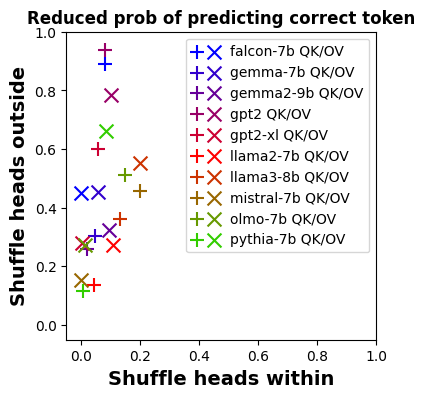

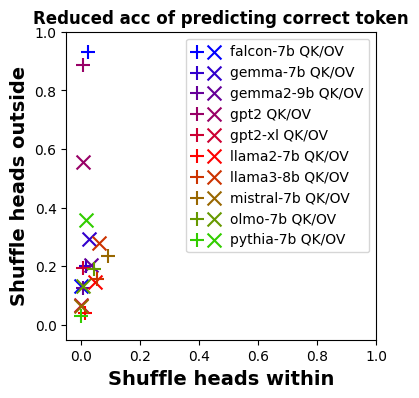

In [3]:
for type in ["prob", "acc"]:
    d_qk, d_ov = collect_all_models(type=type)
    aggregate_shuffle_results(d_qk, d_ov, type=type)

    with open(
        os.path.join(RESULTS_DIR, f"shuffle_summary_{type}.log"), "a"
    ) as log_file:
        log_file.write(f"Shuffle type: {type}\n")
        log_file.write("QK\n")
        for model_name in MODEL_CLASSES:
            try:
                log_file.write(
                    f"""{model_name} 
                        {d_qk[model_name]['original']['mean']:.2f}, {d_qk[model_name]['original']['std']:.2f} 
                        {d_qk[model_name]['inside']['mean']:.2f}, {d_qk[model_name]['inside']['std']:.2f} 
                        {d_qk[model_name]['outside']['mean']:.2f}, {d_qk[model_name]['outside']['std']:.2f}
                    """
                )
            except KeyError:
                log_file.write(f"Model {model_name} not found\n")

        log_file.write("\n\n")
        log_file.write("OV\n")
        for model_name in MODEL_CLASSES:
            try:
                log_file.write(
                    f"""{model_name} 
                        {d_ov[model_name]['original']['mean']:.2f}, {d_ov[model_name]['original']['std']:.2f} 
                        {d_ov[model_name]['inside']['mean']:.2f}, {d_ov[model_name]['inside']['std']:.2f} 
                        {d_ov[model_name]['outside']['mean']:.2f}, {d_ov[model_name]['outside']['std']:.2f}
                    """
                )
            except KeyError:
                log_file.write(f"Model {model_name} not found\n")

# Project

In [4]:
from src.evaluate_projection import ProjectionResult


def load_results_projection(model_name, component):
    fname = f"{model_name}_projection_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    results = [ProjectionResult(**r) for r in results]

    return results


def summarise_result(result):
    d_model = result.model_details["hidden_size"]
    K = max(50, int(0.05 * d_model / 10) * 10)
    rank = result.result["rank"]
    acc = result.result["acc"]
    return acc[0], acc[rank.index(K)]


def plot_projection_results():
    import matplotlib
    from matplotlib.legend_handler import HandlerTuple

    cmap = matplotlib.cm.get_cmap("brg")
    colors = [cmap(t) for t in np.linspace(0, 0.9, len(MODEL_CLASSES))]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    label_handle = []
    label_names = []

    with open(
        os.path.join(RESULTS_DIR, f"projection_summary_acc.log"), "a"
    ) as log_file:

        for i, model_name in enumerate(sorted(MODEL_CLASSES.keys())):
            r_proj_true, r_proj_false = load_results_projection(model_name, "qk")
            acc_baseline, acc_proj_true = summarise_result(r_proj_true)
            acc_baseline, acc_proj_false = summarise_result(r_proj_false)

            log_file.write(
                f"""{model_name} 
{acc_baseline:.2f} {acc_proj_true:.2f} {acc_proj_false:.2f}
{(acc_baseline - acc_proj_true) / acc_baseline:.2f} {(acc_baseline - acc_proj_false) / acc_baseline:.2f}


"""
            )

            p1 = ax.scatter(
                acc_baseline - acc_proj_true,
                acc_baseline - acc_proj_false,
                marker="+",
                s=100,
                color=colors[i],
            )
            label_handle.append((p1))
            label_names.append(model_name)

    ax.set_xlim((0 - 0.05, 1 + 0.05))
    ax.set_ylim((0 - 0.05, 1 + 0.05))
    l = ax.legend(
        label_handle, label_names, handler_map={tuple: HandlerTuple(ndivide=None)}
    )
    title = "Reduced acc under edited model"
    ax.set_title(title, weight="bold", fontsize=13)
    ax.set_xlabel("Remove subspace", weight="bold", fontsize=14)
    ax.set_ylabel("Keep subspace", weight="bold", fontsize=14)
    plt.savefig(
        os.path.join(RESULTS_DIR, f"projection_summary_acc.png"), bbox_inches="tight"
    )
    plt.show()

/tmp/ipykernel_2338760/3760486263.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


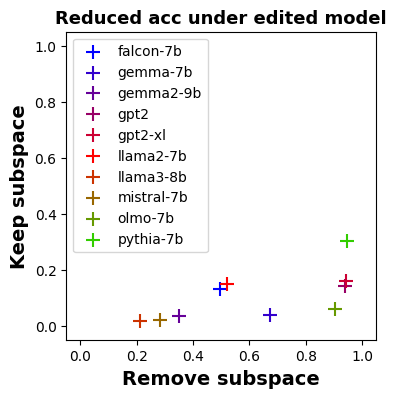

In [5]:
plot_projection_results()